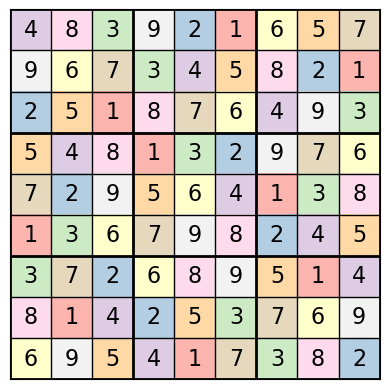

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rows = "ABCDEFGHI"
cols = "123456789"

def cross(A, B):
    return [a + b for a in A for b in B]

cells = cross(rows, cols)

row_units = [cross(r, cols) for r in rows]
col_units = [cross(rows, c) for c in cols]
box_units = [cross(rs, cs) for rs in ("ABC","DEF","GHI") for cs in ("123","456","789")]

units = {s: [u for u in row_units + col_units + box_units if s in u] for s in cells}
peers = {s: set(sum(units[s], [])) - {s} for s in cells}

def parse_grid(grid):
    values = {s: list("123456789") for s in cells}
    for s, d in zip(cells, grid):
        if d in "123456789":
            assign(values, s, d)
    return values

def assign(values, s, d):
    other = [x for x in values[s] if x != d]
    for d2 in other:
        if not eliminate(values, s, d2):
            return False
    return values

def eliminate(values, s, d):
    if d not in values[s]:
        return values
    values[s].remove(d)
    if len(values[s]) == 0:
        return False
    elif len(values[s]) == 1:
        d2 = values[s][0]
        for p in peers[s]:
            if not eliminate(values, p, d2):
                return False
    for u in units[s]:
        dplaces = [sq for sq in u if d in values[sq]]
        if len(dplaces) == 0:
            return False
        elif len(dplaces) == 1:
            if not assign(values, dplaces[0], d):
                return False
    return values

def solve(grid):
    return search(parse_grid(grid))

def search(values):
    if values is False:
        return False
    if all(len(values[s]) == 1 for s in cells):
        return values
    n, s = min((len(values[s]), s) for s in cells if len(values[s]) > 1)
    for d in values[s]:
        res = search(assign(values.copy(), s, d))
        if res:
            return res
    return False

def display(values):
    grid = np.array([int(values[r+c][0]) for r in rows for c in cols]).reshape((9,9))
    fig, ax = plt.subplots()
    ax.imshow(grid, cmap='Pastel1')

    for i in range(10):
        ax.axhline(i-0.5, color='black', linewidth=2 if i%3==0 else 1)
        ax.axvline(i-0.5, color='black', linewidth=2 if i%3==0 else 1)

    for i in range(9):
        for j in range(9):
            ax.text(j, i, grid[i, j], ha='center', va='center', fontsize=16)

    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

grid = "003020600900305001001806400008102900700000008006708200002609500800203009005010300"

solution = solve(grid)

display(solution)